In [ ]:
from cobra.io import read_sbml_model
import pandas as pd
import os
import numpy as np

In [1]:
import os
import pickle
import pandas as pd
import numpy as np
from numpy.random import default_rng
import pyarrow.csv as pv
import xgboost as xgb
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, precision_recall_curve, average_precision_score, roc_auc_score, classification_report
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
import optuna
import shap
#import shapash

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

/depot/pbaloni/data/Lab_members/Boyu_Jiang/Software/.conda/envs/ML2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-07-02 13:21:54.084796: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751476914.757245 3198496 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751476914.877249 3198496 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-02 13:21:55.608921: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available C

## Load AD EN/IN Flux sampling outputs

## Flux sampling

In [ ]:
folder = os.listdir('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/ML_input/Updated_FBA_output_02052025/Flux_sampling/EN')
i = folder[0]
read_path = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/ML_input/Updated_FBA_output_02052025/Flux_sampling/EN/' + i
df = pd.read_csv(read_path, index_col=0)
data = df.sample(n=100, axis=0)
for i in folder[1:]:
    read_path = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/ML_input/Updated_FBA_output_02052025/Flux_sampling/EN/' + i
    df = pd.read_csv(read_path, index_col=0)
    sampled_df = df.sample(n=100, axis=0, random_state=42)
    data = pd.concat([data, sampled_df], axis=0, ignore_index=False)
    

In [ ]:
data.to_csv('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/Flux_Sampling_01162025/EN_100sample.csv')

In [2]:
data = pv.read_csv('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/Flux_Sampling_01162025/EN_100sample.csv')
data = data.to_pandas()
data.set_index(data.columns[0], inplace=True)
data

,EX_5htrp_e,2AMADPTm,2MCITt,2OXOADOXm,3MOPt2im,3MOXTYROX,42A12BOOX,4MPTNLte,4PYRDX,5ADTSTSTERONESULT,...,EX_xtsn_e,GLYLEUPEPT1tc,HC00900t2,EX_Nacasp_e,GLYLEUHYDROc,r1384,C13856te,Sex,Age_of_Death,BRAAK_AD
,,,,,,,,,,,,,,,,,,,,,
AMPAD_HBCC_0000000373_EN_174,None,NaN,0.076446,NaN,0.076446,None,NaN,NaN,None,0.964853,...,-0.024319,NaN,-256.954294,NaN,NaN,-0.024319,0.899552,male,36,NaN
AMPAD_HBCC_0000000373_EN_722,None,NaN,0.965449,NaN,0.965449,None,NaN,NaN,None,0.515952,...,-0.004346,NaN,-158.101459,NaN,NaN,-0.004346,0.149888,male,36,NaN
AMPAD_HBCC_0000000373_EN_769,None,NaN,0.302148,NaN,0.302148,None,NaN,NaN,None,0.348977,...,-0.009636,NaN,-109.688660,NaN,NaN,-0.009636,0.243057,male,36,NaN
AMPAD_HBCC_0000000373_EN_504,None,NaN,0.204659,NaN,0.204659,None,NaN,NaN,None,0.918717,...,-0.011189,NaN,-329.180604,NaN,NaN,-0.011189,0.583857,male,36,NaN
AMPAD_HBCC_0000000373_EN_276,None,NaN,0.172612,NaN,0.172612,None,NaN,NaN,None,0.233669,...,-0.020492,NaN,-257.676865,NaN,NaN,-0.020492,1.000833,male,36,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AMPAD_MSSM_0000991331_EN_436,None,NaN,1.378389,NaN,1.189045,None,NaN,NaN,None,NaN,...,0.186768,NaN,-79.312065,NaN,NaN,0.186768,0.031915,male,59,0.0
AMPAD_MSSM_0000991331_EN_764,None,NaN,1.216310,NaN,1.116305,None,NaN,NaN,None,NaN,...,0.006554,NaN,-181.257589,NaN,NaN,0.006554,-0.493644,male,59,0.0
AMPAD_MSSM_0000991331_EN_88,None,NaN,0.467645,NaN,0.294844,None,NaN,NaN,None,NaN,...,0.261642,NaN,-62.776052,NaN,NaN,0.261642,-0.303201,male,59,0.0


In [3]:
#core_rxn = pd.read_csv('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Code/ML_final_code/core_reaction.csv')
#core_rxn = core_rxn['Reactions_with_Gene'].to_list()

core_rxn = pd.read_csv('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Code/ML_final_code/core_reaction_remove_allTrans.csv')
core_rxn = core_rxn['core_reaction_remove_allTrans'].to_list()

core_rxn = core_rxn + data.columns[-3:].to_list()
data = data[core_rxn]
data_annoted = data
data_annoted

,AGTim,ASNNm,ASNS1,ASPNATm,DASPO1p,NACASPAH,ASPTA,ARGSS,ARGSL,COKECBESr,...,DM_glu__L_syna,DM_4abut_syna,SK_octdececrn_c,DM_glygn2_c,DM_tdechola_c,DM_odecoa_c,DM_stcoa_c,Sex,Age_of_Death,BRAAK_AD
,,,,,,,,,,,,,,,,,,,,,
AMPAD_HBCC_0000000373_EN_174,NaN,0.180120,NaN,NaN,None,NaN,-9.299715,None,None,0.260489,...,1.553755,NaN,NaN,None,NaN,None,NaN,male,36,NaN
AMPAD_HBCC_0000000373_EN_722,NaN,0.933717,NaN,NaN,None,NaN,-11.019860,None,None,1.140337,...,2.394480,NaN,NaN,None,NaN,None,NaN,male,36,NaN
AMPAD_HBCC_0000000373_EN_769,NaN,0.547359,NaN,NaN,None,NaN,-11.828869,None,None,1.171461,...,3.524314,NaN,NaN,None,NaN,None,NaN,male,36,NaN
AMPAD_HBCC_0000000373_EN_504,NaN,0.529390,NaN,NaN,None,NaN,-11.887466,None,None,0.366530,...,2.419622,NaN,NaN,None,NaN,None,NaN,male,36,NaN
AMPAD_HBCC_0000000373_EN_276,NaN,0.374135,NaN,NaN,None,NaN,-10.235425,None,None,0.094135,...,2.153978,NaN,NaN,None,NaN,None,NaN,male,36,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AMPAD_MSSM_0000991331_EN_436,NaN,0.455249,NaN,NaN,None,NaN,-11.181420,None,None,0.425278,...,3.448971,NaN,-1.567704,None,NaN,None,NaN,male,59,0.0
AMPAD_MSSM_0000991331_EN_764,NaN,0.481180,NaN,NaN,None,NaN,-13.315789,None,None,0.391512,...,2.548774,NaN,-0.600379,None,NaN,None,NaN,male,59,0.0
AMPAD_MSSM_0000991331_EN_88,NaN,0.292305,NaN,NaN,None,NaN,-11.614931,None,None,0.307242,...,0.545245,NaN,-1.505730,None,NaN,None,NaN,male,59,0.0


In [4]:
# Grouging based on BRAAK_AD

G_0 =  data_annoted[data_annoted['BRAAK_AD'].isin([0])]


G_1 =  data_annoted[data_annoted['BRAAK_AD'].isin([1])]
G_2 =  data_annoted[data_annoted['BRAAK_AD'].isin([2])]
G_3 =  data_annoted[data_annoted['BRAAK_AD'].isin([3])]
G_4 =  data_annoted[data_annoted['BRAAK_AD'].isin([4])]
G_5 =  data_annoted[data_annoted['BRAAK_AD'].isin([5])]
G_6 =  data_annoted[data_annoted['BRAAK_AD'].isin([6])]

G_1['BRAAK_AD'] = [1] *len(G_1)
G_2['BRAAK_AD'] = [1] *len(G_2)
G_3['BRAAK_AD'] = [1] *len(G_3)
G_4['BRAAK_AD'] = [1] *len(G_4)
G_5['BRAAK_AD'] = [1] *len(G_5)
G_6['BRAAK_AD'] = [1] *len(G_6)

# Comparsion groups
data_G0_G6 = pd.concat([G_0, G_6], ignore_index=False)
data_G0_G6.fillna(0, inplace=True)

data_G0_G5 = pd.concat([G_0, G_5], ignore_index=False)
data_G0_G5.fillna(0, inplace=True)

data_G0_G4 = pd.concat([G_0, G_4], ignore_index=False)
data_G0_G4.fillna(0, inplace=True)

data_G0_G3 = pd.concat([G_0, G_3], ignore_index=False)
data_G0_G3.fillna(0, inplace=True)

data_G0_G2 = pd.concat([G_0, G_2], ignore_index=False)
data_G0_G2.fillna(0, inplace=True)

data_G0_G1 = pd.concat([G_0, G_1], ignore_index=False)
data_G0_G1.fillna(0, inplace=True)

G_1['BRAAK_AD'] = [0] *len(G_1)
G_2['BRAAK_AD'] = [1] *len(G_2)
data_G1_G2 = pd.concat([G_1, G_2], ignore_index=False)
data_G1_G2.fillna(0, inplace=True)


G_2['BRAAK_AD'] = [0] *len(G_2)
G_3['BRAAK_AD'] = [1] *len(G_3)
data_G2_G3 = pd.concat([G_2, G_3], ignore_index=False)
data_G2_G3.fillna(0, inplace=True)


G_3['BRAAK_AD'] = [0] *len(G_3)
G_4['BRAAK_AD'] = [1] *len(G_4)
data_G3_G4 = pd.concat([G_3, G_4], ignore_index=False)
data_G3_G4.fillna(0, inplace=True)


G_4['BRAAK_AD'] = [0] *len(G_4)
G_5['BRAAK_AD'] = [1] *len(G_5)
data_G4_G5 = pd.concat([G_4, G_5], ignore_index=False)
data_G4_G5.fillna(0, inplace=True)


G_5['BRAAK_AD'] = [0] *len(G_5)
G_6['BRAAK_AD'] = [1] *len(G_6)
data_G5_G6 = pd.concat([G_5, G_6], ignore_index=False)
data_G5_G6.fillna(0, inplace=True)

/tmp/ipykernel_3198496/918673452.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  G_1['BRAAK_AD'] = [1] *len(G_1)
/tmp/ipykernel_3198496/918673452.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  G_2['BRAAK_AD'] = [1] *len(G_2)
/tmp/ipykernel_3198496/918673452.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user

/tmp/ipykernel_3198496/918673452.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  G_5['BRAAK_AD'] = [0] *len(G_5)
/tmp/ipykernel_3198496/918673452.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  G_6['BRAAK_AD'] = [1] *len(G_6)
/tmp/ipykernel_3198496/918673452.py:66: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_

## Logistic Regression_Flux sampling

In [5]:
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.feature_selection import VarianceThreshold, RFE
from sklearn.preprocessing import MinMaxScaler

In [6]:
data_HT_AD = data_G0_G6
# data_HT_AD = data_G0_G1
# data_HT_AD = data_G0_G2
# data_HT_AD = data_G0_G3
# data_HT_AD = data_G0_G4
# data_HT_AD = data_G1_G2
# data_HT_AD = data_G2_G3
# data_HT_AD = data_G3_G4
# data_HT_AD = data_G4_G5
data_HT_AD = data_G5_G6
data_HT_AD.fillna(0, inplace=True)
data_HT_AD.drop(data_HT_AD.columns[-3:-1], axis=1, inplace=True)
filtered_df = data_HT_AD
del data_HT_AD
filtered_df

,AGTim,ASNNm,ASNS1,ASPNATm,DASPO1p,NACASPAH,ASPTA,ARGSS,ARGSL,COKECBESr,...,DM_4mop_m,DM_pheme_m,DM_glu__L_syna,DM_4abut_syna,SK_octdececrn_c,DM_glygn2_c,DM_tdechola_c,DM_odecoa_c,DM_stcoa_c,BRAAK_AD
,,,,,,,,,,,,,,,,,,,,,
AMPAD_MSSM_0000066795_EN_521,0.0,2.190725,0.0,1.674219,0,0.0,-9.080484,0,0,1.980256,...,0.0,0.0,2.963069,0.0,0.0,0,0.0,0,0.001620,0
AMPAD_MSSM_0000066795_EN_737,0.0,1.057746,0.0,0.954826,0,0.0,-9.118482,0,0,2.079618,...,0.0,0.0,1.257029,0.0,0.0,0,0.0,0,0.001173,0
AMPAD_MSSM_0000066795_EN_740,0.0,1.211871,0.0,1.072640,0,0.0,-8.898969,0,0,2.051602,...,0.0,0.0,1.553988,0.0,0.0,0,0.0,0,0.001277,0
AMPAD_MSSM_0000066795_EN_660,0.0,1.205591,0.0,1.033760,0,0.0,-8.685220,0,0,1.900683,...,0.0,0.0,3.351701,0.0,0.0,0,0.0,0,0.001414,0
AMPAD_MSSM_0000066795_EN_411,0.0,2.092800,0.0,1.721682,0,0.0,-8.701681,0,0,1.762054,...,0.0,0.0,3.934003,0.0,0.0,0,0.0,0,0.001800,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AMPAD_MSSM_0000065319_EN_436,0.0,0.501156,0.0,0.092686,0,0.0,-10.703038,0,0,1.474274,...,0.0,0.0,3.702188,0.0,0.0,0,0.0,0,0.000000,1
AMPAD_MSSM_0000065319_EN_764,0.0,2.426479,0.0,2.184105,0,0.0,-6.811153,0,0,1.489323,...,0.0,0.0,0.739030,0.0,0.0,0,0.0,0,0.000000,1
AMPAD_MSSM_0000065319_EN_88,0.0,2.778757,0.0,2.321067,0,0.0,-7.354433,0,0,1.497823,...,0.0,0.0,0.632687,0.0,0.0,0,0.0,0,0.000000,1


In [7]:
feature_columns = filtered_df.columns.to_list()[:filtered_df.shape[1]-1]

target_column = 'BRAAK_AD'

X = filtered_df[feature_columns]
y = filtered_df[target_column]

scaler = MinMaxScaler()
X = scaler.fit_transform(X)
X = pd.DataFrame(X, columns=feature_columns)
# Split the data into training and test sets(8:2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=100, stratify=y, shuffle=True)

In [12]:
def hyperopt_obj(params):
    C = params['C']
    max_iter = params['max_iter']
    solver = params['solver']
    
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=100)
    aucs = []  # List to store AUC scores from each fold
    accuracies = []
    model = LogisticRegression(C=C, 
                               penalty='l2',
                               max_iter=max_iter, 
                               solver=solver, 
                               #class_weight='balanced', 
                               random_state=42)
    
    # Stratified K-fold cross-validation on x_train and y_train
    for train_index, val_index in skf.split(X_train, y_train):
        # Split the data into training and validation sets using the indices
        X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
        y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]
        
        
        # Train the model with early stopping based on validation data
        
        
        model.fit(X_train_fold, y_train_fold)
        
        y_pred = model.predict(X_val_fold)
        y_prob = model.predict_proba(X_val_fold)[:, 1]
        
        accuracy = accuracy_score(y_val_fold, y_pred)
        
        accuracies.append(accuracy)
        roc_auc = roc_auc_score(y_val_fold, y_prob)
        aucs.append(roc_auc)  # Store AUC score for the current fold
        
        
    
    mean_auc = np.mean(aucs)
    mean_accuracy = np.mean(accuracies)
    return {"loss": -mean_auc, "status": STATUS_OK}

space = {
    'C': hp.loguniform("C", np.log(0.000001), np.log(0.01)),
    'max_iter':  hp.randint('max_iter', 200, 2000),
    'solver': hp.choice('solver', ['lbfgs', 'liblinear'])
}

trials = Trials()
best_LR = fmin(
    fn = hyperopt_obj,
    space=space,
    algo=tpe.suggest,
    max_evals=2,
    trials=trials,
)


  0%|                                     | 0/2 [00:00<?, ?trial/s, best loss=?]

/tmp/ipykernel_3158875/1912678484.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

/tmp/ipykernel_3158875/1912678484.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

/tmp/ipykernel_3158875/1912678484.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train_fold, y_val_fold = y_train[tr


 50%|█████     | 1/2 [00:06<00:06,  6.75s/trial, best loss: -0.6325046471815671]

/tmp/ipykernel_3158875/1912678484.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

/tmp/ipykernel_3158875/1912678484.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

/tmp/ipykernel_3158875/1912678484.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train_fold, y_val_fold = y_train[tr

100%|██████████| 2/2 [00:22<00:00, 11.34s/trial, best loss: -0.9127930663316288]


In [66]:
from sklearn.model_selection import cross_val_score

final_model = LogisticRegression(C=best_LR['C'], 
                           max_iter=best_LR['max_iter'], 
                           penalty='l2',      
                           random_state=42, 
                           class_weight='balanced',
                           solver=['lbfgs', 'liblinear'][best_LR['solver']])
                           
Stratified_kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
Accuracy = []
F1_score = []
AUC = []
Recall = []
Precision = []
PR_AUC = []
Kappa = []
results = []
fold_num = 0

for train_index, test_index in Stratified_kf.split(X, y):
    fold_num += 1
    X_val_train, X_val_test = X.iloc[train_index], X.iloc[test_index]
    y_val_train, y_val_test = y[train_index], y[test_index]
    
    final_model.fit(X_val_train, y_val_train)
    y_pred = final_model.predict(X_val_test)
    y_prob = final_model.predict_proba(X_val_test)[:, 1]  # Probabilities for the positive class (class 1)
    
    accuracy = accuracy_score(y_val_test, y_pred)
    #kappa = cohen_kappa_score(y_val_test, y_pred)
    f1 = f1_score(y_val_test, y_pred)
    recall = recall_score(y_val_test, y_pred)
    precision = precision_score(y_val_test, y_pred)
    pr_auc = average_precision_score(y_val_test, y_prob)
    roc_auc = roc_auc_score(y_val_test, y_prob)
    
    results.append({
        "Fold": fold_num,
        "Accuracy": accuracy,
        "F1-score": f1,
        "Recall": recall,
        "Precision": precision,
        "Precision-Recall AUC": pr_auc,
        "AUC (ROC Curve)": roc_auc
    })
    

    
results_df = pd.DataFrame(results)
average_results = {
        "Fold": 'Average',
        "Accuracy": results_df['Accuracy'].mean(),
        "F1-score": results_df['F1-score'].mean(),
        "Recall": results_df['Recall'].mean(),
        "Precision": results_df['Precision'].mean(),
        "Precision-Recall AUC": results_df['Precision-Recall AUC'].mean(),
        "AUC (ROC Curve)": results_df['AUC (ROC Curve)'].mean()
    }
average_df = pd.DataFrame([average_results])
results_df = pd.concat([results_df, average_df], ignore_index=True)

''' 
    Accuracy.append(accuracy)
    F1_score.append(f1)
    Kappa.append(kappa)
    AUC.append(roc_auc)
    Recall.append(recall)
    Precision.append(precision)
    PR_AUC.append(pr_auc)
'''
results_df


/tmp/ipykernel_3158875/3282096026.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_val_train, y_val_test = y[train_index], y[test_index]
/tmp/ipykernel_3158875/3282096026.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_val_train, y_val_test = y[train_index], y[test_index]
/tmp/ipykernel_3158875/3282096026.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_val_train, y_val_test = y[train_index], y[test_index]
/tmp/ip

,Fold,Accuracy,F1-score,Recall,Precision,Precision-Recall AUC,AUC (ROC Curve)
0,1,0.805470,0.853373,0.798457,0.916401,0.956909,0.894755
1,2,0.814442,0.860389,0.806481,0.922018,0.962261,0.908538
2,3,0.812473,0.858930,0.805247,0.920282,0.957371,0.901710
3,4,0.821444,0.865922,0.813272,0.925861,0.958444,0.905372
4,5,0.815098,0.860030,0.801235,0.928137,0.957854,0.900828
5,6,0.815974,0.860923,0.803395,0.927325,0.958093,0.900457
6,7,0.810722,0.856669,0.797840,0.924866,0.958482,0.901677
7,8,0.817068,0.862951,0.812346,0.920280,0.956604,0.899726
8,9,0.827352,0.871770,0.827778,0.920700,0.960428,0.907090
9,10,0.824726,0.868365,0.815432,0.928647,0.961776,0.909156


In [ ]:
results_df.to_csv('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/Flux_Sampling_01162025/EN_CROSSVALIDATINO.CSV')

In [ ]:
final_model = LogisticRegression(C=best_LR['C'], 
                           max_iter=best_LR['max_iter'], 
                           penalty='l2',      
                           random_state=42, 
                           class_weight='balanced',
                           solver=['lbfgs', 'liblinear'][best_LR['solver']]
                           
                          )

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class (class 1)


# 1. Accuracy
accuracy = accuracy_score(y_test, y_pred)

# 2. Kappa Score
kappa = cohen_kappa_score(y_test, y_pred)

# 3. F1 Score
f1 = f1_score(y_test, y_pred)

# 4. Recall
recall = recall_score(y_test, y_pred)

# 5. Precision
precision = precision_score(y_test, y_pred)

# 6. Precision-Recall AUC

pr_auc = average_precision_score(y_test, y_prob)

# 7. AUC (ROC Curve)
roc_auc = roc_auc_score(y_test, y_prob)

# Print the results
print(f"Accuracy: {accuracy}")
print(f"Kappa Score: {kappa}")
print(f"F1 Score: {f1}")
print(f"Recall: {recall}")
print(f"Precision: {precision}")
print(f"Precision-Recall AUC: {pr_auc}")
print(f"AUC (ROC Curve): {roc_auc}")

In [47]:
# Calaulate shap value
#explainer = shap.LinearExplainer(final_model, X_train, model_output='probability')
explainer = shap.LinearExplainer(final_model, X_train)
shap_values = explainer.shap_values(X_test)

In [43]:
import pickle
read_folder = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/ML/Shape_values/EN_flux_sampling_100_noTrans/LR/'
save_path_explainer = read_folder + "LR_shap_explainer_g0_g5.pkl"

with open(save_path_explainer, 'rb') as f:
    explainer = pickle.load(f)

import joblib

# Save the trained logistic regression model to a file
save_path_model = read_folder + "LR_g0_g5.pkl"
final_model = joblib.load(save_path_model) 


save_path_shape_values = read_folder + 'LR_shap_values_all_classes_g0_g5.npy'
shap_values = np.load(save_path_shape_values)

In [44]:
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class (class 1)


# 1. Accuracy
accuracy = accuracy_score(y_test, y_pred)

# 2. Kappa Score
kappa = cohen_kappa_score(y_test, y_pred)

# 3. F1 Score
f1 = f1_score(y_test, y_pred)

# 4. Recall
recall = recall_score(y_test, y_pred)

# 5. Precision
precision = precision_score(y_test, y_pred)

# 6. Precision-Recall AUC

pr_auc = average_precision_score(y_test, y_prob)

# 7. AUC (ROC Curve)
roc_auc = roc_auc_score(y_test, y_prob)

# Print the results
print(f"Accuracy: {accuracy}")
print(f"Kappa Score: {kappa}")
print(f"F1 Score: {f1}")
print(f"Recall: {recall}")
print(f"Precision: {precision}")
print(f"Precision-Recall AUC: {pr_auc}")
print(f"AUC (ROC Curve): {roc_auc}")

Accuracy: 0.8462585034013606
Kappa Score: 0.6920381545649212
F1 Score: 0.8371757925072046
Recall: 0.8736842105263158
Precision: 0.8035961272475796
Precision-Recall AUC: 0.90890509101653
AUC (ROC Curve): 0.9265662214542569


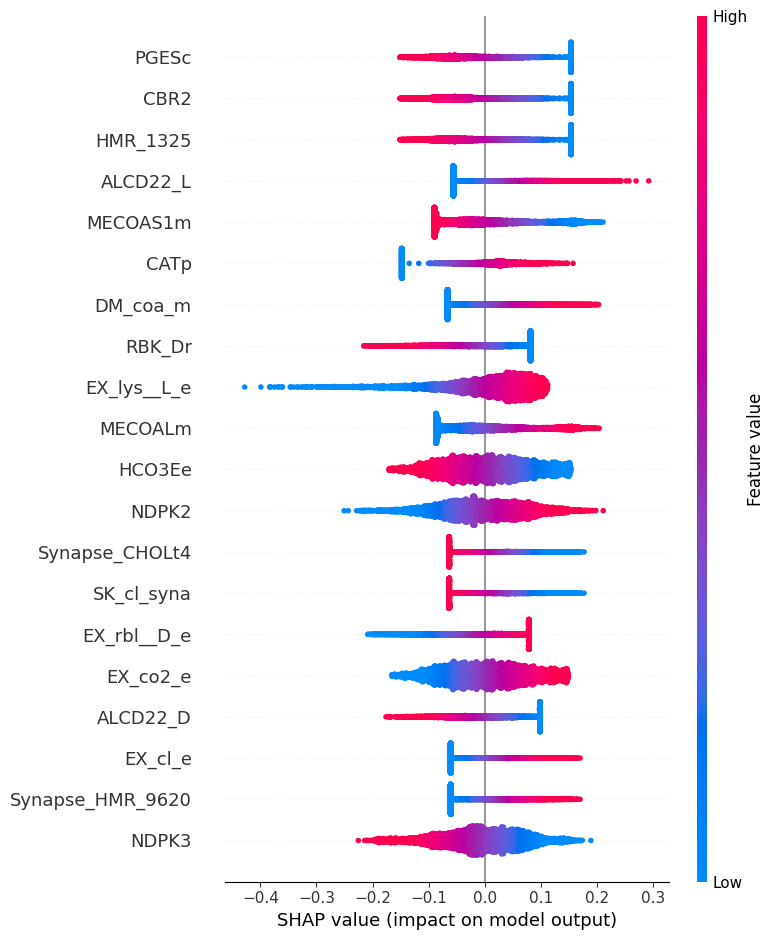

In [48]:
#shap_values_class_0 = shap_values[:97, :, 0]
# shap_values_class_0.shape

mean_shap_values = np.mean(np.abs(shap_values), axis=0) 

# Step 2: Take the absolute value of the mean SHAP values
#mean_shap_values = np.abs(mean_shap_values)

top_features_indices = list(np.argsort(mean_shap_values)[::-1][:100])

X_test_filtered = X_test.iloc[:, top_features_indices]
shap_values_filtered = shap_values[:, top_features_indices]

shap.summary_plot(shap_values_filtered, X_test_filtered)

In [ ]:
mean_shap_values_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean SHAP Value': mean_shap_values
})
mean_shap_values_df.to_csv('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/ML/Shape_values/EN_flux_sampling_100_noTrans/LR/mean_abs_shape_lr_g0_g5.csv')


In [ ]:
import pickle
# save_folder = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/ML/Shape_values/EN_flux_sampling_100/LR/'
save_folder = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/ML/Shape_values/EN_flux_sampling_100_noTrans/LR/'

save_path_explainer = save_folder + "LR_shap_explainer_g0_g5.pkl"

with open(save_path_explainer, 'wb') as f:
    pickle.dump(explainer, f)

import joblib

# Save the trained logistic regression model to a file
save_path_model = save_folder + "LR_g0_g5.pkl"
joblib.dump(final_model, save_path_model)


save_path_shape_values = save_folder + 'LR_shap_values_all_classes_g0_g5.npy'
np.save(save_path_shape_values, shap_values)



## Random Forest_Flux sampling

In [ ]:
# Grouging based on BRAAK_AD

G_0 =  data_annoted[data_annoted['BRAAK_AD'].isin([0])]


G_1 =  data_annoted[data_annoted['BRAAK_AD'].isin([1])]
G_2 =  data_annoted[data_annoted['BRAAK_AD'].isin([2])]
G_3 =  data_annoted[data_annoted['BRAAK_AD'].isin([3])]
G_4 =  data_annoted[data_annoted['BRAAK_AD'].isin([4])]
G_5 =  data_annoted[data_annoted['BRAAK_AD'].isin([5])]
G_6 =  data_annoted[data_annoted['BRAAK_AD'].isin([6])]

G_1['BRAAK_AD'] = [1] *len(G_1)
G_2['BRAAK_AD'] = [1] *len(G_2)
G_3['BRAAK_AD'] = [1] *len(G_3)
G_4['BRAAK_AD'] = [1] *len(G_4)
G_5['BRAAK_AD'] = [1] *len(G_5)
G_6['BRAAK_AD'] = [1] *len(G_6)

# Comparsion groups
data_G0_G6 = pd.concat([G_0, G_6], ignore_index=False)
data_G0_G6.fillna(0, inplace=True)

data_G0_G5 = pd.concat([G_0, G_5], ignore_index=False)
data_G0_G5.fillna(0, inplace=True)

data_G0_G4 = pd.concat([G_0, G_4], ignore_index=False)
data_G0_G4.fillna(0, inplace=True)

data_G0_G3 = pd.concat([G_0, G_3], ignore_index=False)
data_G0_G3.fillna(0, inplace=True)

data_G0_G2 = pd.concat([G_0, G_2], ignore_index=False)
data_G0_G2.fillna(0, inplace=True)

data_G0_G1 = pd.concat([G_0, G_1], ignore_index=False)
data_G0_G1.fillna(0, inplace=True)

In [ ]:
#data_HT_AD = data_G0_G6
#data_HT_AD = data_G0_G1
#data_HT_AD = data_G0_G2
#data_HT_AD = data_G0_G3
#data_HT_AD = data_G0_G4
data_HT_AD = data_G0_G5
data_HT_AD.fillna(0, inplace=True)
data_HT_AD.drop(data_HT_AD.columns[-3:-1], axis=1, inplace=True)
filtered_df = data_HT_AD
del data_HT_AD
filtered_df


filtered_df

In [ ]:
feature_columns = filtered_df.columns.to_list()[:filtered_df.shape[1]-1]
# define tag column
target_column = 'BRAAK_AD'

X = filtered_df[feature_columns]
y = filtered_df[target_column]

scaler = MinMaxScaler()
X = scaler.fit_transform(X)
X = pd.DataFrame(X, columns=feature_columns)
# Split the data into training and test sets(8:2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=100, stratify=y, shuffle=True)


In [ ]:
print(len(G_0))
print(len(G_5))

In [ ]:
def objective(trial):
    # Define the hyperparameter search space
    param = {'n_estimators': trial.suggest_int('n_estimators', 1000,2000),  # Number of trees in the forest
        'max_depth': trial.suggest_int('max_depth', 4, 5, log=True), # Max depth of trees (log scale)
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 4),  # Min samples to split
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 4),    # Min samples per leaf
        'max_features': trial.suggest_categorical('max_features', [ 'sqrt', 'log2']),  # Features per split
        'bootstrap': trial.suggest_categorical('bootstrap', [True]),  # Whether bootstrap samples are used
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss'])  # Criterion for split  
                                               }
                                        
            

    # Create the RandomForestClassifier with the suggested parameters
    model = RandomForestClassifier(**param, 
                                   class_weight='balanced',
                                   random_state=42, 
                                   n_jobs=-1)

    # Fit the model on the training data
    model.fit(X_train, y_train)

    # Get the predicted probabilities on the test set
    y_prob = model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class (class 1)
    
    # Calculate AUC using roc_auc_score
    auc = roc_auc_score(y_test, y_prob)
    
    y_pred = model.predict(X_test)

    # Calculate the accuracy of the model
    accuracy = accuracy_score(y_test, y_pred)
    
    
    return 1 - auc  

study = optuna.create_study(direction='minimize')  # Minimize the objective 
study.optimize(objective, n_trials=5)  # Run the optimization with 50 trials

# Print the best hyperparameters found by Optuna
print("Best hyperparameters found:", study.best_params)

# Print the best AUC score
print("Best score:", 1 - study.best_value)


In [ ]:
def objective(trial):
    # Define the hyperparameter search space
    param = {'n_estimators': trial.suggest_int('n_estimators', 100,3000),  # Number of trees in the forest
        'max_depth': trial.suggest_int('max_depth', 1, 6, log=True), # Max depth of trees (log scale)
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 4),  # Min samples to split
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 4),    # Min samples per leaf
        'max_features': trial.suggest_categorical('max_features', [ 'sqrt', 'log2']),  # Features per split
        'bootstrap': trial.suggest_categorical('bootstrap', [True]),  # Whether bootstrap samples are used
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss'])  # Criterion for split  
                                               }
                                        
            

    # Create the RandomForestClassifier with the suggested parameters
    model = RandomForestClassifier(**param, 
                                   class_weight='balanced',
                                   random_state=42)
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=100)
    aucs = []  # List to store AUC scores from each fold
    accuracies = []
    
    for train_index, val_index in skf.split(X_train, y_train):
        # Split the data into training and validation sets using the indices
        X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
        y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]
        
        model.fit(X_train_fold, y_train_fold)
        y_pred = model.predict(X_val_fold)
        y_prob = model.predict_proba(X_val_fold)[:, 1]
        
        accuracy = accuracy_score(y_val_fold, y_pred)
        
        accuracies.append(accuracy)
        roc_auc = roc_auc_score(y_val_fold, y_prob)
        aucs.append(roc_auc)  # Store AUC score for the current fold
        
   
    mean_auc = np.mean(aucs)
    mean_accuracy = np.mean(accuracies)
    performance = mean_auc + mean_accuracy
    

    
    
    return 1 - mean_auc  

study = optuna.create_study(direction='minimize')  # Minimize the objective 
study.optimize(objective, n_trials=3)  # Run the optimization with 50 trials

# Print the best hyperparameters found by Optuna
print("Best hyperparameters found:", study.best_params)

# Print the best AUC score
print("Best score:", 1 - study.best_value)


In [ ]:
from sklearn.model_selection import cross_val_score

best_params = study.best_params


final_model = RandomForestClassifier(**best_params, 
                                     class_weight='balanced',
                                     random_state=42, 
                                     n_jobs= -1)

Stratified_kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
Accuracy = []
F1_score = []
AUC = []
Recall = []
Precision = []
PR_AUC = []
Kappa = []
results = []
fold_num = 0

for train_index, test_index in Stratified_kf.split(X, y):
    fold_num += 1
    X_val_train, X_val_test = X.iloc[train_index], X.iloc[test_index]
    y_val_train, y_val_test = y[train_index], y[test_index]
    
    final_model.fit(X_val_train, y_val_train)
    y_pred = final_model.predict(X_val_test)
    y_prob = final_model.predict_proba(X_val_test)[:, 1]  # Probabilities for the positive class (class 1)
    
    accuracy = accuracy_score(y_val_test, y_pred)
    kappa = cohen_kappa_score(y_val_test, y_pred)
    f1 = f1_score(y_val_test, y_pred)
    recall = recall_score(y_val_test, y_pred)
    precision = precision_score(y_val_test, y_pred)
    pr_auc = average_precision_score(y_val_test, y_prob)
    roc_auc = roc_auc_score(y_val_test, y_prob)
    
    results.append({
        "Fold": fold_num,
        "Accuracy": accuracy,
        "F1-score": f1,
        "Recall": recall,
        "Precision": precision,
        "Precision-Recall AUC": pr_auc,
        "AUC (ROC Curve)": roc_auc
    })
    

    
results_df = pd.DataFrame(results)
average_results = {
        "Fold": 'Average',
        "Accuracy": results_df['Accuracy'].mean(),
        "F1-score": results_df['F1-score'].mean(),
        "Recall": results_df['Recall'].mean(),
        "Precision": results_df['Precision'].mean(),
        "Precision-Recall AUC": results_df['Precision-Recall AUC'].mean(),
        "AUC (ROC Curve)": results_df['AUC (ROC Curve)'].mean()
    }
average_df = pd.DataFrame([average_results])
results_df = pd.concat([results_df, average_df], ignore_index=True)

''' 
    Accuracy.append(accuracy)
    F1_score.append(f1)
    Kappa.append(kappa)
    AUC.append(roc_auc)
    Recall.append(recall)
    Precision.append(precision)
    PR_AUC.append(pr_auc)
'''
results_df


In [ ]:
results_df.to_csv('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/Flux_Sampling_01162025/EN_CROSSVALIDATINO.CSV')

In [ ]:
best_params = study.best_params


final_model = RandomForestClassifier(**best_params, 
                                     class_weight='balanced',
                                     random_state=42, 
                                     n_jobs=-1)
final_model.fit(X_train, y_train)


y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class (class 1)

# 1. Accuracy
accuracy = accuracy_score(y_test, y_pred)

# 2. Kappa Score
kappa = cohen_kappa_score(y_test, y_pred)

# 3. F1 Score
f1 = f1_score(y_test, y_pred)

# 4. Recall
recall = recall_score(y_test, y_pred)

# 5. Precision
precision = precision_score(y_test, y_pred)

# 6. Precision-Recall AUC
#precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
#pr_auc = auc(recall_vals, precision_vals)

# 7. AUC (ROC Curve)
roc_auc = roc_auc_score(y_test, y_prob)

# Print the results
print(f"Accuracy: {accuracy}")
print(f"Kappa Score: {kappa}")
print(f"F1 Score: {f1}")
print(f"Recall: {recall}")
print(f"Precision: {precision}")
#print(f"Precision-Recall AUC: {pr_auc}")
print(f"AUC (ROC Curve): {roc_auc}")


In [ ]:
explainer = shap.TreeExplainer(final_model, X_train)
shap_values = explainer.shap_values(X_test)


In [ ]:
import pickle
read_folder = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/ML/Shape_values/EN_FVA/Logistic_regression/'
save_path_explainer = read_folder + "shap_explainer_CoreRxn.pkl"

with open(save_path_explainer, 'rb') as f:
    explainer = pickle.load(f)

import joblib

# Save the trained logistic regression model to a file
save_path_model = read_folder + "logisticRegression_model_CoreRxn.pkl"
final_model = joblib.load(save_path_model) 


save_path_shape_values = read_folder + 'shap_values_all_classes_CoreRxn.npy'
shap_values = np.load(save_path_shape_values)

In [ ]:
shap_values_class_0 = shap_values[:, :, 0]

mean_shap_values = np.mean(np.abs(shap_values_class_0), axis=0) 

# Step 2: Take the absolute value of the mean SHAP values
#mean_shap_values = np.abs(mean_shap_values)

top_features_indices = list(np.argsort(mean_shap_values)[::-1][:100])

X_test_filtered = X_test.iloc[:, top_features_indices]
shap_values_filtered = shap_values_class_0[:, top_features_indices]

shap.summary_plot(shap_values_filtered, X_test_filtered)

In [ ]:
mean_shap_values_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean SHAP Value': mean_shap_values
})
mean_shap_values_df.to_csv('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/ML/Shape_values/EN_flux_sampling_100_noTrans/RF/mean_abs_shape_rf_g0_g5.csv')


In [ ]:
import pickle
save_folder = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/ML/Shape_values/EN_flux_sampling_100_noTrans/RF/'
save_path_explainer = save_folder + "RF_shap_explainer_g0_g5.pkl"

with open(save_path_explainer, 'wb') as f:
    pickle.dump(explainer, f)

import joblib

# Save the trained logistic regression model to a file
save_path_model = save_folder + "RF_g0_g5.pkl"
joblib.dump(final_model, save_path_model)


save_path_shape_values = save_folder + 'RF_shap_values_all_classes_g0_g5.npy'
np.save(save_path_shape_values, shap_values)

## Xgboost_Flux_sampling

In [21]:
# Grouging based on BRAAK_AD

G_0 =  data_annoted[data_annoted['BRAAK_AD'].isin([0])]


G_1 =  data_annoted[data_annoted['BRAAK_AD'].isin([1])]
G_2 =  data_annoted[data_annoted['BRAAK_AD'].isin([2])]
G_3 =  data_annoted[data_annoted['BRAAK_AD'].isin([3])]
G_4 =  data_annoted[data_annoted['BRAAK_AD'].isin([4])]
G_5 =  data_annoted[data_annoted['BRAAK_AD'].isin([5])]
G_6 =  data_annoted[data_annoted['BRAAK_AD'].isin([6])]

G_1['BRAAK_AD'] = [1] *len(G_1)
G_2['BRAAK_AD'] = [1] *len(G_2)
G_3['BRAAK_AD'] = [1] *len(G_3)
G_4['BRAAK_AD'] = [1] *len(G_4)
G_5['BRAAK_AD'] = [1] *len(G_5)
G_6['BRAAK_AD'] = [1] *len(G_6)

# Comparsion groups
data_G0_G6 = pd.concat([G_0, G_6], ignore_index=False)
data_G0_G6.fillna(0, inplace=True)

data_G0_G5 = pd.concat([G_0, G_5], ignore_index=False)
data_G0_G5.fillna(0, inplace=True)

data_G0_G4 = pd.concat([G_0, G_4], ignore_index=False)
data_G0_G4.fillna(0, inplace=True)

data_G0_G3 = pd.concat([G_0, G_3], ignore_index=False)
data_G0_G3.fillna(0, inplace=True)

data_G0_G2 = pd.concat([G_0, G_2], ignore_index=False)
data_G0_G2.fillna(0, inplace=True)

data_G0_G1 = pd.concat([G_0, G_1], ignore_index=False)
data_G0_G1.fillna(0, inplace=True)

/tmp/ipykernel_1387744/3269954665.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_1387744/3269954665.py:14: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_1387744/3269954665.py:15: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ip

In [22]:
#data_HT_AD = data_G0_G6
#data_HT_AD = data_G0_G1
#data_HT_AD = data_G0_G2
#data_HT_AD = data_G0_G3
#data_HT_AD = data_G0_G4
data_HT_AD = data_G0_G5
data_HT_AD.fillna(0, inplace=True)
data_HT_AD.drop(data_HT_AD.columns[-3:-1], axis=1, inplace=True)
filtered_df = data_HT_AD
del data_HT_AD
filtered_df

,AGTim,ASNNm,ASNS1,ASPNATm,DASPO1p,NACASPAH,ASPTA,ARGSS,ARGSL,COKECBESr,...,DM_4mop_m,DM_pheme_m,DM_glu__L_syna,DM_4abut_syna,SK_octdececrn_c,DM_glygn2_c,DM_tdechola_c,DM_odecoa_c,DM_stcoa_c,BRAAK_AD
,,,,,,,,,,,,,,,,,,,,,
AMPAD_MSSM_0000014502_EN_521,0.0,1.372285,0.0,0.0,0,0.0,-12.577299,0,0,0.000000,...,0.0,0.0,0.281066,0.0,0.0,0,0.0,0,0.0,0.0
AMPAD_MSSM_0000014502_EN_737,0.0,0.840023,0.0,0.0,0,0.0,-10.476793,0,0,0.000000,...,0.0,0.0,5.011464,0.0,0.0,0,0.0,0,0.0,0.0
AMPAD_MSSM_0000014502_EN_740,0.0,0.731961,0.0,0.0,0,0.0,-10.255594,0,0,0.000000,...,0.0,0.0,4.881529,0.0,0.0,0,0.0,0,0.0,0.0
AMPAD_MSSM_0000014502_EN_660,0.0,2.042142,0.0,0.0,0,0.0,-9.046965,0,0,0.000000,...,0.0,0.0,2.434101,0.0,0.0,0,0.0,0,0.0,0.0
AMPAD_MSSM_0000014502_EN_411,0.0,0.677678,0.0,0.0,0,0.0,-14.085570,0,0,0.000000,...,0.0,0.0,0.377097,0.0,0.0,0,0.0,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AMPAD_MSSM_0000049781_EN_436,0.0,0.924464,0.0,0.0,0,0.0,-7.865584,0,0,1.268260,...,0.0,0.0,1.587398,0.0,0.0,0,0.0,0,0.0,1.0
AMPAD_MSSM_0000049781_EN_764,0.0,1.774778,0.0,0.0,0,0.0,-3.455462,0,0,1.266881,...,0.0,0.0,5.760551,0.0,0.0,0,0.0,0,0.0,1.0
AMPAD_MSSM_0000049781_EN_88,0.0,0.851054,0.0,0.0,0,0.0,-9.627277,0,0,0.897336,...,0.0,0.0,2.543778,0.0,0.0,0,0.0,0,0.0,1.0


In [463]:
print(len(G_0))
print(len(G_4))

16100
12100


In [462]:
feature_columns = filtered_df.columns.to_list()[:filtered_df.shape[1]-1]
# define tag column
target_column = 'BRAAK_AD'

X = filtered_df[feature_columns]
y = filtered_df[target_column]

scaler = MinMaxScaler()
X = scaler.fit_transform(X)
X = pd.DataFrame(X, columns=feature_columns)
# Split the data into training and test sets(8:2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=100, stratify=y, shuffle=True)

dtrain = xgb.DMatrix(data=X_train, label=y_train, feature_names=X_train.columns.to_list())
dtest = xgb.DMatrix(data=X_test, label=y_test, feature_names=X_test.columns.to_list())

In [465]:
def hyperopt_objective(params):

    params['objective'] = 'binary:logistic'
    params['eval_metric'] = 'logloss'
  
    
    evallist = [(X_train, y_train), X_test, y_test]
        
    # Train the model with early stopping based on validation data
    model = xgb.XGBClassifier(
        n_estimators = int(params['n_estimators']),
        max_depth = int(params['max_depth']),
        eta = params['eta'],
        gamma = params['gamma'],
        subsample = params['subsample'],
        colsample_bytree = params['colsample_bytree'],
        reg_lambda = params['lambda'],
        reg_alpha = params['alpha'],
        early_stopping_rounds=int(params['n_estimators'])*0.1,
        eval_metric = 'logloss',
        scale_pos_weight = params['scale_pos_weight'],
        max_delta_step = params['max_delta_step'],
        n_jobs = -1
    )
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        
        verbose=False)
    
    # Get predictions on the validation set and compute AUC
    
    y_pred = model.predict(X_test)

  
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    
    #auc = roc_auc_score(y_test, y_pred_prob)  # Calculate ROC AUC for validation set
        
   
    
    # Return the negative of the average AUC score across all folds
   
    return {'loss': -accuracy, 'status': STATUS_OK}


from hyperopt.pyll.base import scope

params_space = {
            'gamma': hp.loguniform('gamma', np.log(0.0001), np.log(3)) - 0.0001,
            'max_depth': scope.int(hp.uniform('max_depth', 1, 4)),
            'subsample': hp.uniform('subsample', 0.5, 0.8),
            'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 0.7),
            'colsample_bylevel': hp.uniform('colsample_bylevel', 0.5, 0.7),
            'lambda': hp.loguniform('lambda', np.log(1), np.log(4)),
            'alpha': hp.loguniform('alpha', np.log(0.8), np.log(1)) - 0.0001,
            'eta': hp.loguniform('eta', np.log(0.3), np.log(0.5)),
            'scale_pos_weight': hp.uniform('scale_pos_weight',1.2,1.3),
            #'scale_pos_weight': hp.uniform('scale_pos_weight',0.4,0.6),
            'max_delta_step':hp.uniform('max_delta_step', 0, 5),
            'n_estimators': hp.randint('n_estimators', 10, 500)
            
                     }


trials = Trials()

rng = default_rng(123)

best = fmin(
    hyperopt_objective,         # The objective function to minimize
    space=params_space,         # The hyperparameter search space
    algo=tpe.suggest,           # The algorithm for optimization
    max_evals=1,                # Number of trials to evaluate
    trials=trials,              # Store the results of each trial
    rstate=rng                  # Random state for reproducibility
)


  0%|                                     | 0/1 [00:00<?, ?trial/s, best loss=?]

INFO:hyperopt.tpe:build_posterior_wrapper took 0.001839 seconds
INFO:hyperopt.tpe:TPE using 0 trials


100%|██████████| 1/1 [00:15<00:00, 15.55s/trial, best loss: -0.9921768707482993]


In [466]:
# xbgclassifier
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score,precision_recall_curve, auc
# Prepare the StratifiedKFold
Stratified_kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Create empty lists to store metrics
results = []
fold_num = 0

# Loop through each fold for cross-validation
for train_index, test_index in Stratified_kf.split(X, y):
    fold_num += 1
    X_val_train, X_val_test = X.iloc[train_index], X.iloc[test_index]
    y_val_train, y_val_test = y[train_index], y[test_index]
    

    
    # Train the model using xgb.train
    final_model = xgb.XGBClassifier(
        n_estimators = int(best['n_estimators']),
        max_depth = int(best['max_depth']),
        eta = best['eta'],
        gamma = best['gamma'],
        subsample = best['subsample'],
        colsample_bytree = best['colsample_bytree'],
        reg_lambda = best['lambda'],
        reg_alpha = best['alpha'],
        early_stopping_rounds=int(best['n_estimators'])*0.1,
        eval_metric = 'logloss',
        scale_pos_weight = best['scale_pos_weight'],
        max_delta_step = best['max_delta_step'],
        n_jobs = -1
        
    )
    

    final_model.fit(X_val_train, y_val_train,
                   eval_set=[(X_val_test, y_val_test)],
                   verbose=False)
    
    # Make predictions
    y_pred = final_model.predict(X_val_test)
    y_pre_prob = final_model.predict_proba(X_val_test)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_val_test, y_pred)
    f1 = f1_score(y_val_test, y_pred)
    recall = recall_score(y_val_test, y_pred)
    precision = precision_score(y_val_test, y_pred)
    precision_values, recall_values, _ = precision_recall_curve(y_val_test, y_pre_prob)
    pr_auc = auc(recall_values, precision_values)
    roc_auc = roc_auc_score(y_val_test, y_pre_prob)
    
    # Store results for each fold
    results.append({
        "Fold": fold_num,
        "Accuracy": accuracy,
        "F1-score": f1,
        "Recall": recall,
        "Precision": precision,
        "Precision-Recall AUC": pr_auc,
        "AUC (ROC Curve)": roc_auc

    })

# Create a DataFrame from the results of each fold
results_df = pd.DataFrame(results)

# Calculate average results across all folds
average_results = {
    "Fold": 'Average',
    "Accuracy": results_df['Accuracy'].mean(),
    "F1-score": results_df['F1-score'].mean(),
    "Recall": results_df['Recall'].mean(),
    "Precision": results_df['Precision'].mean(),
    "Precision-Recall AUC": results_df['Precision-Recall AUC'].mean(),
    "AUC (ROC Curve)": results_df['AUC (ROC Curve)'].mean()
}

# Add the average results to the DataFrame
average_df = pd.DataFrame([average_results])
results_df = pd.concat([results_df, average_df], ignore_index=True)

# Display the final results
results_df

/tmp/ipykernel_275269/1026954071.py:14: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_275269/1026954071.py:14: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_275269/1026954071.py:14: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_275269/1026954071.py:14: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as l

,Fold,Accuracy,F1-score,Recall,Precision,Precision-Recall AUC,AUC (ROC Curve)
0,1,0.986395,0.985052,0.990977,0.979198,0.997791,0.998208
1,2,0.990476,0.989505,0.992481,0.986547,0.999125,0.999213
2,3,0.982313,0.980669,0.991729,0.969853,0.998842,0.999034
3,4,0.983673,0.982103,0.990226,0.974112,0.998209,0.998542
4,5,0.987415,0.986179,0.992481,0.979955,0.998769,0.998809
5,6,0.983673,0.982009,0.984962,0.979073,0.998779,0.998935
6,7,0.987755,0.986587,0.995489,0.977843,0.998526,0.999117
7,8,0.988435,0.987332,0.996241,0.978582,0.999316,0.999417
8,9,0.984014,0.982430,0.987970,0.976952,0.998933,0.999049
9,10,0.983333,0.981791,0.993233,0.970610,0.998215,0.998621


In [ ]:
# Define the parameters for the XGBoost model

# Prepare the StratifiedKFold
Stratified_kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Create empty lists to store metrics
results = []
fold_num = 0

# Loop through each fold for cross-validation
for train_index, test_index in Stratified_kf.split(X, y):
    fold_num += 1
    X_val_train, X_val_test = X.iloc[train_index], X.iloc[test_index]
    y_val_train, y_val_test = y[train_index], y[test_index]
    
    # Convert to DMatrix format for XGBoost
    dtrain_fold = xgb.DMatrix(X_val_train, label=y_val_train)
    dtest_fold = xgb.DMatrix(X_val_test, label=y_val_test)
    
    # Train the model using xgb.train
    final_model = xgb.train(params, dtrain_fold, params['n_estimators'], evals=[(dtest, 'test')], early_stopping_rounds=params['n_estimators']*0.1, verbose_eval=False)
    
    # Make predictions
    y_pred = final_model.predict(dtest_fold)
    y_pred_binary = (y_pred > 0.5).astype(int)  # Convert probabilities to binary class predictions
    y_prob = y_pred  # Probabilities for the positive class (class 1)
    
    # Calculate metrics
    accuracy = accuracy_score(y_val_test, y_pred_binary)
    kappa = cohen_kappa_score(y_val_test, y_pred_binary)
    f1 = f1_score(y_val_test, y_pred_binary)
    recall = recall_score(y_val_test, y_pred_binary)
    precision = precision_score(y_val_test, y_pred_binary)
    pr_auc = average_precision_score(y_val_test, y_prob)
    roc_auc = roc_auc_score(y_val_test, y_prob)
    
    # Store results for each fold
    results.append({
        "Fold": fold_num,
        "Accuracy": accuracy,
        "F1-score": f1,
        "Recall": recall,
        "Precision": precision,
        "Precision-Recall AUC": pr_auc,
        "AUC (ROC Curve)": roc_auc,
        "Kappa": kappa
    })

# Create a DataFrame from the results of each fold
results_df = pd.DataFrame(results)

# Calculate average results across all folds
average_results = {
    "Fold": 'Average',
    "Accuracy": results_df['Accuracy'].mean(),
    "F1-score": results_df['F1-score'].mean(),
    "Recall": results_df['Recall'].mean(),
    "Precision": results_df['Precision'].mean(),
    "Precision-Recall AUC": results_df['Precision-Recall AUC'].mean(),
    "AUC (ROC Curve)": results_df['AUC (ROC Curve)'].mean()
}

# Add the average results to the DataFrame
average_df = pd.DataFrame([average_results])
results_df = pd.concat([results_df, average_df], ignore_index=True)

# Display the final results
results_df

In [ ]:
results_df.to_csv('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/Flux_Sampling_01162025/EN_CROSSVALIDATINO.CSV')

In [ ]:
# Make predictions using the model

params['objective'] = 'binary:logistic'
params['eval_metric'] = 'logloss'
   
final_model = xgb.train(params, dtrain, params['n_estimators'], evals=[(dtest, 'test')], early_stopping_rounds=params['n_estimators']*0.1, verbose_eval=False)       


y_pred_prob = final_model.predict(dtest)




# Predicted class labels (0 or 1)
y_pred = (y_pred_prob > 0.5).astype(int)
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
pr_auc = average_precision_score(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_pred_prob)
# Print the evaluation metrics

print("XGBoost Accuracy:", accuracy)
print("Kappa Score:", kappa)
print("F1 Score:", f1)
print("Recall:", recall)
print("Precision:", precision)
print("Precision-Recall Curve:", pr_auc)
print("AUC:", auc)

In [474]:
# xbgClassifier

final_model = xgb.XGBClassifier(
    n_estimators = int(best['n_estimators']),
    max_depth = int(best['max_depth']),
    eta = best['eta'],
    gamma = best['gamma'],
    subsample = best['subsample'],
    colsample_bytree = best['colsample_bytree'],
    reg_lambda = best['lambda'],
    reg_alpha = best['alpha'],
    early_stopping_rounds=int(best['n_estimators'])*0.1,
    eval_metric = 'logloss',
    scale_pos_weight = best['scale_pos_weight'],
    max_delta_step = best['max_delta_step'],
    n_jobs = -1
        
)
    

final_model.fit(X_train, y_train,
                eval_set=[(X_test, y_test)],
                verbose=False)


y_pred = final_model.predict(X_test)
y_pre_prob = final_model.predict_proba(X_test)[:, 1]
    
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
precision_values, recall_values, _ = precision_recall_curve(y_test, y_pre_prob)
pr_auc = auc(recall_values, precision_values)
roc_auc = roc_auc_score(y_test, y_pre_prob)



print("XGBoost Accuracy:", accuracy)
print("F1 Score:", f1)
print("Recall:", recall)
print("Precision:", precision)
print("Precision-Recall Curve:", pr_auc)
print("AUC:", roc_auc)

XGBoost Accuracy: 0.9921768707482993
F1 Score: 0.9913696060037523
Recall: 0.9932330827067669
Precision: 0.9895131086142323
Precision-Recall Curve: 0.9991609826078272
AUC: 0.9991770770092934


In [481]:
explainer = shap.TreeExplainer(final_model, X_train)
shap_values = explainer.shap_values(X_test)

100%|===================| 5878/5880 [00:18<00:00]        

In [23]:
import pickle
read_folder = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/ML/Shape_values/EN_flux_sampling_100_noTrans/XGBOOST/'
save_path_explainer = read_folder + "XGBOOST_shap_explainer_g0_g5.pkl"

with open(save_path_explainer, 'rb') as f:
    explainer = pickle.load(f)

import joblib

# Save the trained logistic regression model to a file
save_path_model = read_folder + "XGBOOST_g0_g5.pkl"
final_model = joblib.load(save_path_model) 


save_path_shape_values = read_folder + 'XGBOOST_shap_values_all_classes_g0_g5.npy'
shap_values = np.load(save_path_shape_values)

In [26]:
final_model.fit(X_train, y_train,
                eval_set=[(X_test, y_test)],
                verbose=False)


y_pred = final_model.predict(X_test)
y_pre_prob = final_model.predict_proba(X_test)[:, 1]
    
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
precision_values, recall_values, _ = precision_recall_curve(y_test, y_pre_prob)
pr_auc = auc(recall_values, precision_values)
roc_auc = roc_auc_score(y_test, y_pre_prob)



print("XGBoost Accuracy:", accuracy)
print("F1 Score:", f1)
print("Recall:", recall)
print("Precision:", precision)
print("Precision-Recall Curve:", pr_auc)
print("AUC:", roc_auc)

NameError: name 'auc' is not defined

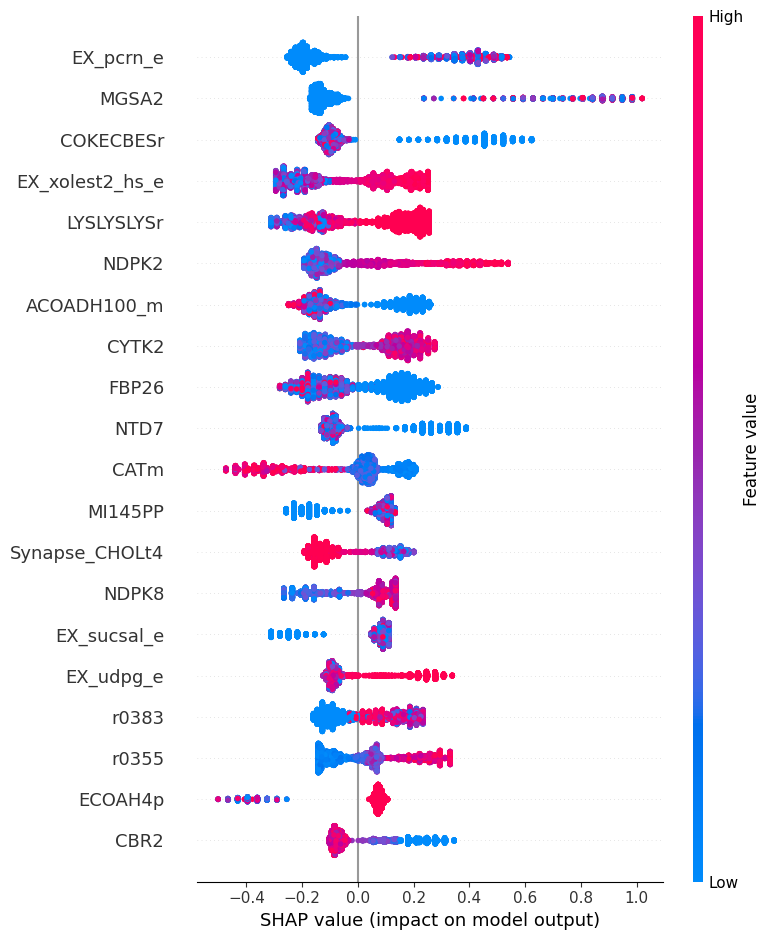

In [482]:
shap_values_class_0 = shap_values


mean_shap_values = np.mean(np.abs(shap_values_class_0), axis=0) 

# Step 2: Take the absolute value of the mean SHAP values
#mean_shap_values = np.abs(mean_shap_values)

top_features_indices = list(np.argsort(mean_shap_values)[::-1][:100])

X_test_filtered = X_test.iloc[:, top_features_indices]
shap_values_filtered = shap_values_class_0[:, top_features_indices]

shap.summary_plot(shap_values_filtered, X_test_filtered)

In [483]:
mean_shap_values_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean SHAP Value': mean_shap_values
})
mean_shap_values_df.to_csv('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/ML/Shape_values/EN_flux_sampling_100_noTrans/XGBOOST/mean_abs_shape_xgboost_g0_g5.csv')


In [484]:
import pickle
save_folder = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/ML/Shape_values/EN_flux_sampling_100_noTrans/XGBOOST/'
save_path_explainer = save_folder + "XGBOOST_shap_explainer_g0_g5.pkl"

with open(save_path_explainer, 'wb') as f:
    pickle.dump(explainer, f)

import joblib

# Save the trained logistic regression model to a file
save_path_model = save_folder + "XGBOOST_g0_g5.pkl"
joblib.dump(final_model, save_path_model)


save_path_shape_values = save_folder + 'XGBOOST_shap_values_all_classes_g0_g5.npy'
np.save(save_path_shape_values, shap_values)